In [ ]:
# Install dependencies (if needed)
# %pip install torch torchvision torchaudio matplotlib numpy tqdm

import os, math, random, time
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
@dataclass
class ModArithConfig:
    p: int = 97                 # prime modulus
    op: str = "div"             # 'add' | 'sub' | 'mul' | 'div'
    split_frac: float = 0.5     # 50/50 split to induce grokking
    one_hot: bool = True

def mod_inverse(b, p):
    # Fermat's little theorem: b^(p-2) mod p for prime p and b != 0
    return pow(b, p-2, p)

def make_table(cfg: ModArithConfig):
    xs, ys = [], []
    P = cfg.p
    # Build all valid pairs for the chosen op
    for a in range(P):
        for b in range(P):
            if cfg.op == "div":
                if b == 0:
                    continue  # skip non-invertible case
                c = (a * mod_inverse(b, P)) % P
            elif cfg.op == "add":
                c = (a + b) % P
            elif cfg.op == "sub":
                c = (a - b) % P
            elif cfg.op == "mul":
                c = (a * b) % P
            else:
                raise ValueError("Unknown op")
            xs.append((a, b))
            ys.append(c)
    xs = np.array(xs, dtype=np.int64)
    ys = np.array(ys, dtype=np.int64)
    return xs, ys

class ModDataset(Dataset):
    def __init__(self, cfg: ModArithConfig):
        super().__init__()
        self.cfg = cfg
        X, y = make_table(cfg)
        # Shuffle then split 50/50
        idx = np.arange(len(X))
        np.random.shuffle(idx)
        X, y = X[idx], y[idx]
        n_train = int(len(X) * cfg.split_frac)
        self.X_train, self.y_train = X[:n_train], y[:n_train]
        self.X_val, self.y_val = X[n_train:], y[n_train:]

    def one_hot_cat(self, a, b):
        P = self.cfg.p
        v = np.zeros(2*P, dtype=np.float32)
        v[a] = 1.0
        v[P + b] = 1.0
        return v

# Build dataset
cfg = ModArithConfig(p=97, op="div", split_frac=0.5, one_hot=True)
ds = ModDataset(cfg)

len_train = len(ds.X_train)
len_val = len(ds.X_val)
len_train, len_val


(4656, 4656)

In [ ]:
def collate_batch(batch_pairs, ys, start, end, P, one_hot=True):
    Xp = batch_pairs[start:end]
    yp = ys[start:end]
    if one_hot:
        X_mat = np.zeros((len(Xp), 2*P), dtype=np.float32)
        for i, (a, b) in enumerate(Xp):
            X_mat[i, a] = 1.0
            X_mat[i, P + b] = 1.0
        X_tensor = torch.from_numpy(X_mat)
    else:
        X_tensor = torch.from_numpy(Xp.astype(np.int64))
    y_tensor = torch.from_numpy(yp.astype(np.int64))
    return X_tensor, y_tensor


class TableLoader:
    def __init__(self, X, y, P, batch_size=512, shuffle=True, one_hot=True):
        self.X, self.y = X, y
        self.P = P
        self.bs = batch_size
        self.shuffle = shuffle
        self.one_hot = one_hot
        self.perm = np.arange(len(X))
        self.reset()

    def reset(self):
        if self.shuffle:
            np.random.shuffle(self.perm)
        self.ptr = 0

    # FIX: correct iterator method; remove the invalid "__iter.me__"
    def __iter__(self):
        self.reset()
        return self

    # Optional but useful: let len(loader) report number of batches
    def __len__(self):
        return (len(self.X) + self.bs - 1) // self.bs

    def __next__(self):
        if self.ptr >= len(self.X):
            raise StopIteration
        end = min(self.ptr + self.bs, len(self.X))
        idx = self.perm[self.ptr:end]
        Xb, yb = collate_batch(self.X[idx], self.y[idx], 0, len(idx), self.P, self.one_hot)
        self.ptr = end
        return Xb, yb


batch_size = 512
train_loader = TableLoader(ds.X_train, ds.y_train, cfg.p, batch_size=batch_size, shuffle=True,  one_hot=True)
val_loader   = TableLoader(ds.X_val,   ds.y_val,   cfg.p, batch_size=batch_size, shuffle=False, one_hot=True)


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=2*cfg.p, hidden_dim=128, output_dim=cfg.p).to(device)
sum(p.numel() for p in model.parameters())


37473

In [ ]:
import torch

def agop_info(history, epoch_agop, k=4):
    """
    Compute ONLY the AGOP metrics required for the plotting cell:
      - Frobenius norm
      - Spectral radius (λ₁)
      - Trace
      - Eigengap (λ₁ − λ₂)
      - Top-k subspace similarity
    """

    # ---------- Eigen-decomposition ----------
    eigvals, eigvecs = torch.linalg.eigh(epoch_agop)

    lambda1 = eigvals[-1].item()
    lambda2 = eigvals[-2].item()

    # Top-k eigenvectors for subspace tracking
    U_k = eigvecs[:, -k:].cpu()

    # ---------- Store basic scalars ----------
    history.setdefault("agop_frobenius", []).append(
        torch.norm(epoch_agop, p="fro").item()
    )
    history.setdefault("agop_spectral_radius", []).append(lambda1)
    history.setdefault("agop_trace", []).append(eigvals.sum().item())
    history.setdefault("agop_eigengap", []).append(lambda1 - lambda2)

    # ---------- Top-k subspace similarity ----------
    history.setdefault("agop_topk_subspace_prev", None)
    history.setdefault("agop_topk_subspace_similarity", [])

    if history["agop_topk_subspace_prev"] is None:
        history["agop_topk_subspace_similarity"].append(float("nan"))
    else:
        U_prev = history["agop_topk_subspace_prev"]
        M = U_k.T @ U_prev
        svals = torch.linalg.svdvals(M)
        history["agop_topk_subspace_similarity"].append(svals.mean().item())

    history["agop_topk_subspace_prev"] = U_k


In [ ]:
def accuracy(logits, y):
    preds = logits.argmax(dim=-1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def run_eval(model, loader):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    for Xb, yb in TableLoader(loader.X, loader.y, loader.P, batch_size=loader.bs, shuffle=False, one_hot=loader.one_hot):
        Xb = Xb.to(device)
        yb = yb.to(device)
        logits = model(Xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(dim=-1) == yb).sum().item()
        total += yb.size(0)
    return correct/total, total_loss/total

# Optimizer (strong weight decay is important to elicit grokking)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.98), weight_decay=1.0)

max_epochs = 3000         # Increase substantially (e.g., 10k+) for full grokking runs
log_every = 1

history = {
    "epoch": [],
    "train_acc": [],
    "train_loss": [],
    "val_acc": [],
    "val_loss": [],
}


pbar = tqdm(range(1, max_epochs+1))
for epoch in pbar:
    model.train()
    epoch_loss, n_seen = 0.0, 0
    agop_sum = None  # store accumulated gradient outer products

    # fresh iterator each epoch
    train_loader.reset()
    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        # forward pass
        logits = model(Xb)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        # Compute per-example input gradient (∇_x f(x))
        Xb.requires_grad_(True)  # ensure Xb is a leaf that tracks gradients
        logits = model(Xb)

        # Choose scalar function to differentiate
        # (mean logit for true class gives more meaningful sensitivity)
        f_scalar = logits[torch.arange(yb.size(0)), yb].mean()

        # Compute ∇_x f(x)
        grads = torch.autograd.grad(
            outputs=f_scalar, inputs=Xb,
            retain_graph=False, create_graph=False
        )[0]  # shape: [B, d]

        # Compute average gradient outer product for the batch
        g_outer = torch.einsum('bi,bj->bij', grads, grads)  # [B, d, d]
        batch_agop = g_outer.mean(dim=0)  # [d, d]
        agop_sum = batch_agop if agop_sum is None else agop_sum + batch_agop


        optimizer.step()

        epoch_loss += loss.item() * yb.size(0)
        n_seen += yb.size(0)

    # Average AGOP for the epoch
    epoch_agop = agop_sum / len(train_loader)
    trn_loss = epoch_loss / n_seen

    # update AGOP history
    agop_info(history, epoch_agop)

    # Metrics
    trn_acc, _ = run_eval(model, train_loader)
    val_acc, val_loss = run_eval(model, val_loader)

    history["epoch"].append(epoch)
    history["train_acc"].append(trn_acc)
    history["train_loss"].append(trn_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)
    history.setdefault("agop", []).append(epoch_agop.detach().cpu().numpy())  # store AGOP matrix

    if epoch % log_every == 0:
        pbar.set_description(
            f"ep {epoch} | trn_acc {trn_acc:.3f} val_acc {val_acc:.3f} trn_loss {trn_loss:.3f} val_loss {val_loss:.3f}"
        )


  0%|          | 0/3000 [00:00<?, ?it/s]

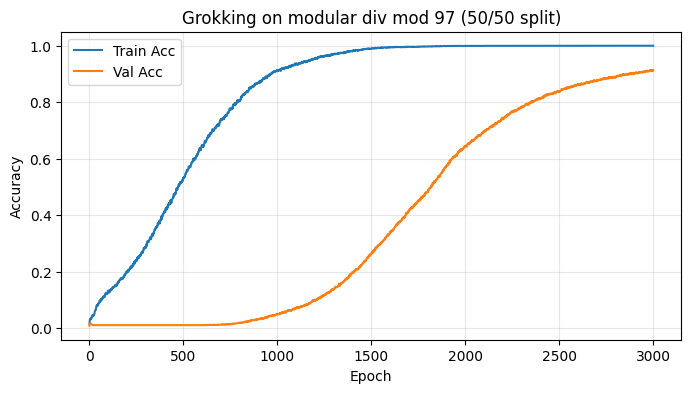

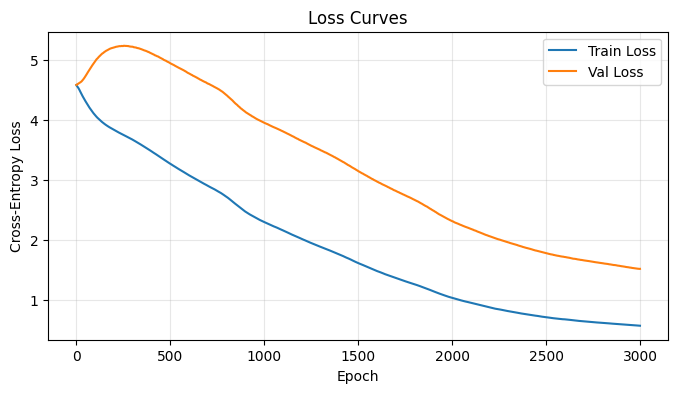

In [ ]:
epochs = np.array(history["epoch"])
plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"],   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Grokking on modular {cfg.op} mod {cfg.p} (50/50 split)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


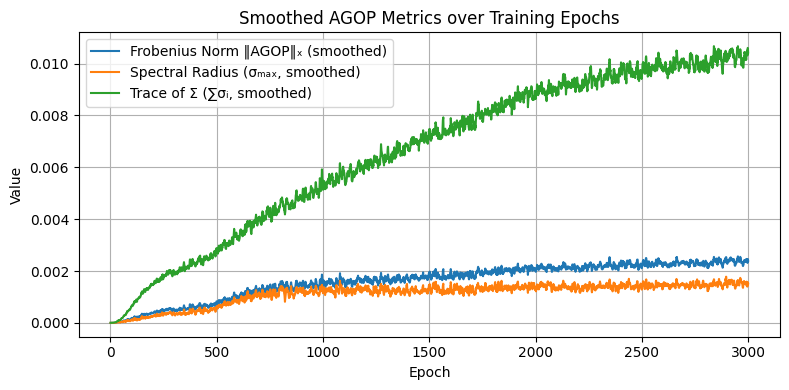

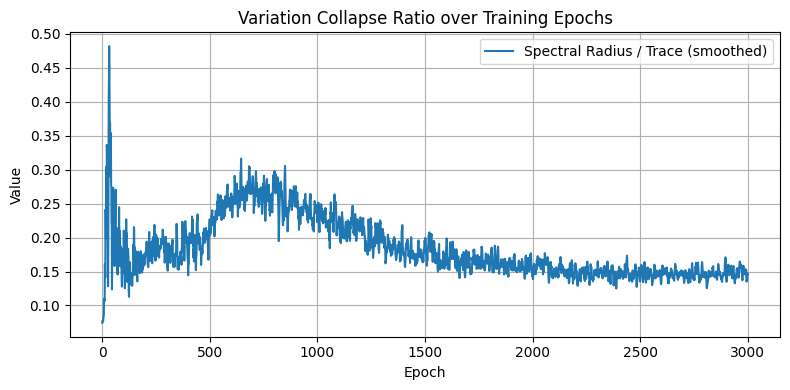

In [ ]:
 import numpy as np
import matplotlib.pyplot as plt

epochs = np.array(history["epoch"])
frobenius = np.array(history["agop_frobenius"])
spectral = np.array(history["agop_spectral_radius"])
trace_vals = np.array(history["agop_trace"])

def smooth_series(x, window=5):
    smoothed = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        # take average over up to last `window` elements (or all previous if < window)
        start = max(0, i - window + 1)
        smoothed[i] = np.mean(x[start:i + 1])
    return smoothed

frobenius_smooth = smooth_series(frobenius)
spectral_smooth = smooth_series(spectral)
trace_smooth = smooth_series(trace_vals)

# Compute elementwise ratio (spectral / trace)
variation_collapse_ratio = spectral_smooth / trace_smooth

# Plot smoothed metrics
plt.figure(figsize=(8,4))
plt.plot(epochs, frobenius_smooth, label="Frobenius Norm ‖AGOP‖ₓ (smoothed)")
plt.plot(epochs, spectral_smooth, label="Spectral Radius (σₘₐₓ, smoothed)")
plt.plot(epochs, trace_smooth, label="Trace of Σ (∑σᵢ, smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Smoothed AGOP Metrics over Training Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ratio
plt.figure(figsize=(8,4))
plt.plot(epochs, variation_collapse_ratio, label="Spectral Radius / Trace (smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Variation Collapse Ratio over Training Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_agop_metrics(history):
    epochs = np.arange(1, len(history["agop_frobenius"]) + 1)

    def smooth_series(x, window=5):
        smoothed = np.zeros_like(x, dtype=float)
        for i in range(len(x)):
            # take average over up to last `window` elements (or all previous if < window)
            start = max(0, i - window + 1)
            smoothed[i] = np.mean(x[start:i + 1])
        return smoothed

    # Calculate smoothed metrics for the new plot
    frobenius = np.array(history["agop_frobenius"])
    spectral = np.array(history["agop_spectral_radius"])
    trace_vals = np.array(history["agop_trace"])

    # Note: frobenius_smooth is computed but not used in this specific request's plot.
    frobenius_smooth = smooth_series(frobenius)
    spectral_smooth = smooth_series(spectral)
    trace_smooth = smooth_series(trace_vals)

    # Compute elementwise ratio (spectral / trace)
    variation_collapse_ratio = spectral_smooth / trace_smooth

    # ==============================================
    # FIRST FIGURE — Spectral and Eigengap Metrics
    # ==============================================
    plt.figure(figsize=(12, 6)) # Adjusted figsize for 1 row, 2 columns layout

    # ---- Spectral radius and Trace (Combined) ----
    plt.subplot(1, 2, 1) # First subplot in 1 row, 2 columns
    plt.plot(epochs, history["agop_spectral_radius"], label="Spectral Radius λ₁", color="C1")
    plt.plot(epochs, history["agop_trace"], label="Trace Σ λᵢ", color="C2", linestyle='--') # Add linestyle for distinction
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Spectral Radius and Trace of AGOP over Training")
    plt.legend()
    plt.grid(True)

    # ---- Eigengap ----
    plt.subplot(1, 2, 2) # Second subplot in 1 row, 2 columns
    plt.plot(epochs, history["agop_eigengap"], label="Eigengap λ₁ − λ₂", color="C3")
    plt.xlabel("Epoch")
    plt.ylabel("Eigengap")
    plt.title("Eigengap over Training")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))

    # ==============================================
    # FIGURE — Variation Collapse Ratio (NEW)
    # ==============================================

    plt.subplot(1, 2, 1) # First subplot in 1 row, 2 columns
    plt.plot(epochs, variation_collapse_ratio, label="Spectral Radius / Trace (smoothed)")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Variation Collapse Ratio over Training Epochs")
    plt.legend()
    plt.grid(True)


    # ==============================================
    # FIGURE — AGOP Directional Metrics
    # ==============================================

    # ---- 7. Top-k subspace similarity ----
    plt.subplot(1, 2, 2) # Adjusted subplot position
    plt.plot(epochs, history["agop_topk_subspace_similarity"],
             label="Top-k Subspace Similarity", color="C6")
    plt.xlabel("Epoch")
    plt.ylabel("Similarity")
    plt.title("Top-k (k=3) Subspace Stability")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # ---- 5. Smoothed eigenvector cosine similarity (Commented Out) ----
    # plt.subplot(2, 2, 1) # This subplot is commented out as per user request
    # plt.plot(epochs, history["agop_cosine_smooth"], label="Cosine(sim) smoothed top eigenvector", color="C4")
    # plt.xlabel("Epoch")
    # plt.ylabel("Cosine Similarity")
    # plt.title("Stability of Top Eigenvector (Smoothed)")
    # plt.grid(True)

    # max eigenvalue / trace ratio = repeat
    # # ---- 6. Energy ratio λ₁ / trace ----
    # plt.subplot(1, 2, 1) # Adjusted subplot position
    # plt.plot(epochs, history["agop_energy_ratio"], label="Energy Ratio λ₁ / Tr", color="C5")
    # plt.xlabel("Epoch")
    # plt.ylabel("Ratio")
    # plt.title("Energy Concentration into Top Eigenvector")
    # plt.grid(True)

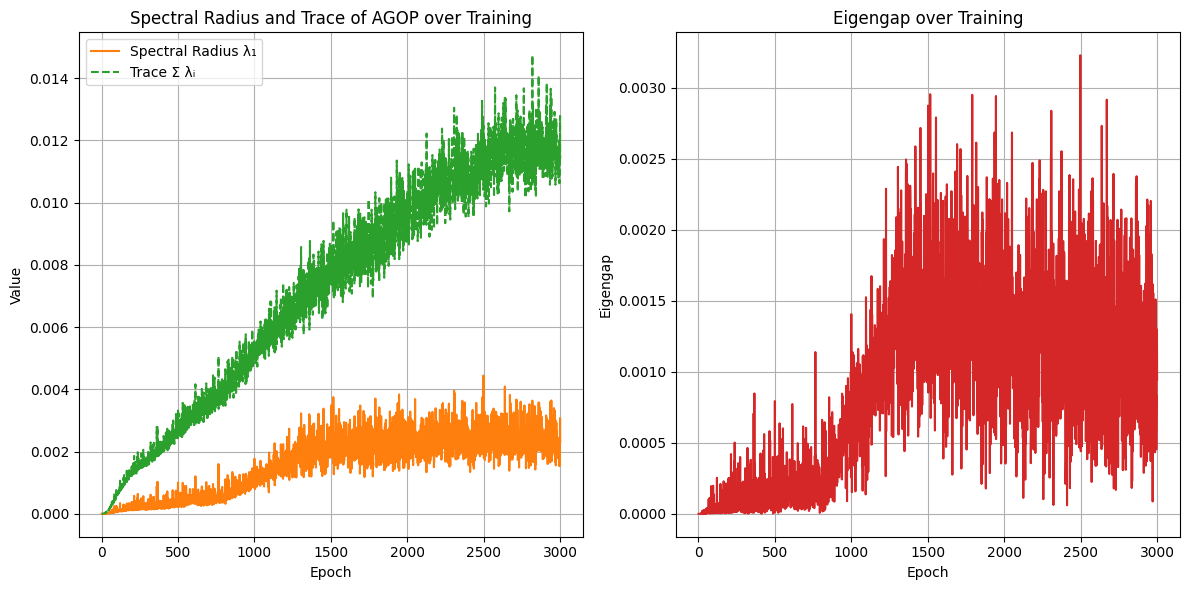

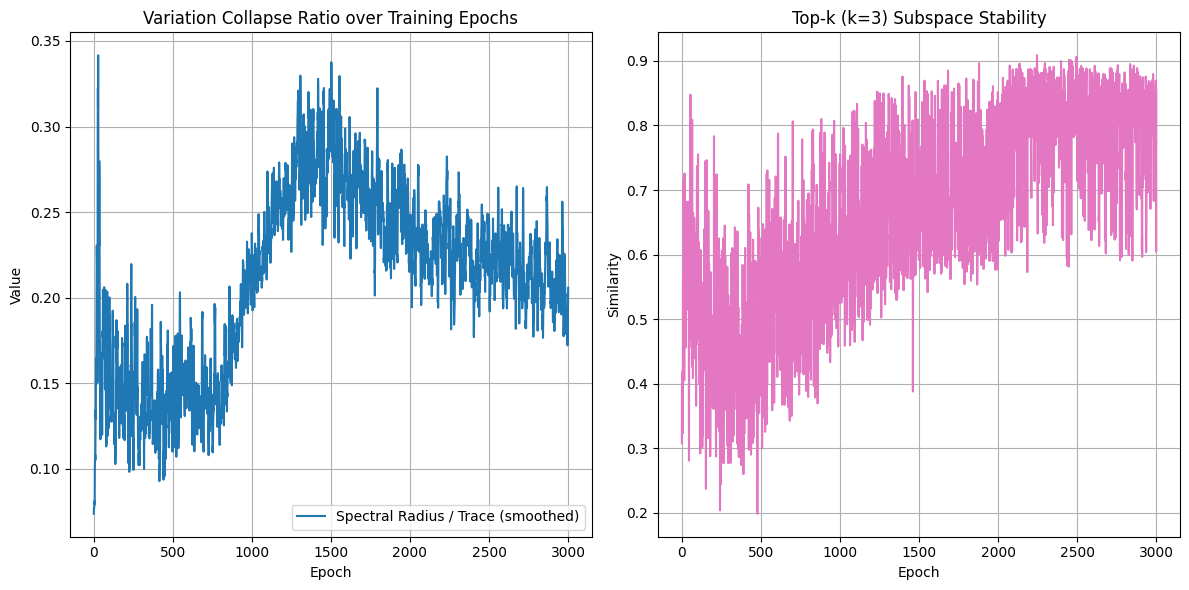

In [ ]:
plot_agop_metrics(history)